# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph, sample a connected subgraph, and narrate it.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NodeContextConfig,
    OpenAISubgraphNarrator,
    SubgraphNarrativeConfig,
    SubgraphNarrativePrompt,
    sample_random_connected_subgraph,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

## Configure and run

In [2]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
ABSTRACT_PATH = ASSETS_ROOT / 'abstracts' / 'pathogen_abstract_nipah_virus.txt'
ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'

abstract_text = load_text(ABSTRACT_PATH)
ontology = load_ontology(ONTOLOGY_PATH)
ENTITY_EFFORT = 0.1
RELATION_EFFORT = 1.5
density = ExtractionDensityConfig(
    entities_per_word=ENTITY_EFFORT,
    relations_per_entity=RELATION_EFFORT,
)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    model='gpt-4o-mini',
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
    casting_retries=1,
)

graphicalizer = Graphicalizer.from_openai(ontology, config)
result = graphicalizer.run(abstract_text)

In [3]:
print('Model:', config.model)
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))

Model: gpt-4o-mini
Source SHA-256: 42466a9525771b6f88f34965debc73799d4e2e4e24ceb6ba20097bf948388589
Raw validation: {'valid': False, 'connected': False, 'sparse': True, 'node_count': 9, 'edge_count': 8, 'density': 0.2222222222222222, 'max_neighbor_count': 4, 'hub_nodes': (), 'issues': ('graph is disconnected',), 'density_ok': True, 'hubs_ok': True}
Normalized validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 7, 'edge_count': 8, 'density': 0.38095238095238093, 'max_neighbor_count': 4, 'hub_nodes': ('e1',), 'issues': ('graph contains 1 hub node(s): e1',), 'density_ok': True, 'hubs_ok': False}
Normalization report: {'policy': 'largest_component', 'component_count': 3, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e9'), 'discarded_entity_ids': ('e7', 'e8'), 'retained_relation_ids': ('r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8'), 'discarded_relation_ids': ()}
Final validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 7, '

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="virus\nNipah virus", shape=box];
  "e2" [label="animal_population\nfruit bats", shape=box];
  "e3" [label="human_host\nhumans", shape=box];
  "e4" [label="contaminated_material\nraw date-palm sap", shape=box];
  "e5" [label="clinical_syndrome\nacute febrile encephalitis", shape=box];
  "e6" [label="geographic_location\nBangladesh", shape=box];
  "e9" [label="animal_population\nPteropus bats", shape=box];
  "e1" -> "e5" [color="#555555", label="causes_infection"];
  "e1" -> "e6" [color="#555555", label="occurred_in"];
  "e2" -> "e4" [color="#555555", label="contaminates"];
  "e2" -> "e5" [color="#555555", label="exposes"];
  "e3" -> "e2" [color="#555555", label="associated_with"];
  "e3" -> "e5" [color="#555555", label="presents_with"];
  "e4" -> "e1" [color="#555555", label="causes_infection"];
  "e9" -> "e1" [color="#555555", label="supports"];
}



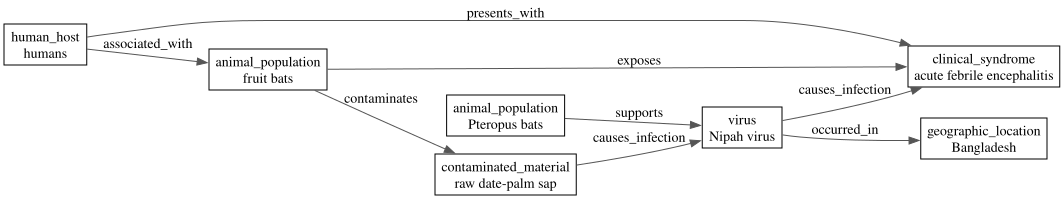

In [4]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Sample and narrate a connected subgraph

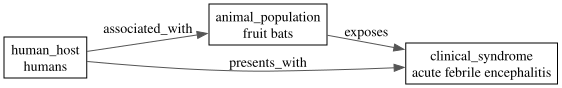

In [5]:
SUBGRAPH_NODE_COUNT = 3
SUBGRAPH_SEED = 17
NARRATIVE_WORDS = 100
SUBGRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_random_subgraph.svg'
NARRATIVE_PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'subgraph_narrative_prompt_template.yaml'
NARRATIVE_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'subgraph-narrator-0.1.0.yaml'

sampled_subgraph = sample_random_connected_subgraph(
    result.typed_graph,
    num_nodes=SUBGRAPH_NODE_COUNT,
    seed=SUBGRAPH_SEED,
)
validate_ontology_labeled_graph(sampled_subgraph)
render_graph(
    sampled_subgraph,
    SUBGRAPH_OUTPUT_PATH,
    graph_name='NipahRandomSubgraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(SUBGRAPH_OUTPUT_PATH)))

In [6]:

narrator_prompt = SubgraphNarrativePrompt.from_yaml_file(NARRATIVE_PROMPT_PATH)
narrator = OpenAISubgraphNarrator.from_graphicalizer(
    graphicalizer,
    prompt=narrator_prompt,
    prompt_snapshot_path=NARRATIVE_SNAPSHOT_PATH,
)
narrative = narrator.narrate(
    sampled_subgraph,
    SubgraphNarrativeConfig(target_words=NARRATIVE_WORDS),
)
print(narrative.narrative)
print('Requested words:', narrative.requested_words)
print('Actual words:', narrative.actual_words)
if narrative.uncertainty:
    print('Uncertainty:', narrative.uncertainty)


Acute febrile encephalitis is a clinical syndrome characterized by symptoms such as fever and altered mental status, confirming its association with Nipah virus infection. This infection primarily affects humans, who can contract the virus through contact with infected animals, particularly fruit bats of the genus Pteropus, as well as via contaminated food sources. Evidence indicates that fruit bats serve as the reservoir for Nipah virus, thus exposing humans to the pathogen through contaminated materials, such as raw date-palm sap. The significant interconnectedness among these entities underscores the zoonotic transmission dynamics of Nipah virus in rural agricultural communities in Bangladesh.
Requested words: 100
Actual words: 99
Uncertainty: None identified in the provided data.


## Inspect node contexts

In [7]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {node_context.summary}')
    for evidence in node_context.evidence:
        print(f'  evidence: {evidence}')
    if node_context.uncertainty:
        print(f'  uncertainty: {node_context.uncertainty}')


[e1] Nipah virus, a zoonotic pathogen maintained in fruit bats (Pteropus spp.), causes infection in humans through contaminated date-palm sap consumption.
  evidence: The findings support a zoonotic spillover pathway in which Pteropus fruit bats contaminate raw date-palm sap, followed by infection of humans who consume the untreated product.
  evidence: Nipah virus infection was confirmed in patients with fever, altered mental status, and rapidly progressive encephalitis.
  uncertainty: None.

[e2] Fruit bats serve as a reservoir for the Nipah virus, contaminating raw date-palm sap, which is linked to human infections.
  evidence: Human infection has been associated with direct contact with infected animals, exposure to contaminated food, and subsequent person-to-person transmission.
  evidence: Nipah virus contamination from fruit bats to raw date-palm sap is supported by findings of viral RNA in sap collected from trees.
  uncertainty: None.

[e3] Humans can contract Nipah virus thr